# Network Analysis with ySights

This tutorial demonstrates how to extract and analyze social networks from YSocial simulation data.

## What You'll Learn

- Extracting different types of social networks
- Computing network metrics
- Analyzing ego networks
- Visualizing network structures

---

In [1]:
from ysights import YDataHandler
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Set up visualization
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
# Initialize data handler
db_path = 'ysocial_db.db'
ydh = YDataHandler(db_path)

## 1. Extracting the Social Network

The social network represents connections between agents (follows, friends, etc.).

In [3]:
# Extract the full social network
social_network = ydh.social_network()

print("Social Network Statistics:")
print(f"  Nodes (Agents): {social_network.number_of_nodes()}")
print(f"  Edges (Connections): {social_network.number_of_edges()}")
print(f"  Directed: {social_network.is_directed()}")

Social Network Statistics:
  Nodes (Agents): 993
  Edges (Connections): 29544
  Directed: True


### Network Density

Density measures how connected the network is (0 = no connections, 1 = fully connected).

In [4]:
density = nx.density(social_network)
print(f"Network Density: {density:.4f}")
print(f"  Interpretation: {density*100:.2f}% of all possible connections exist")

Network Density: 0.0300
  Interpretation: 3.00% of all possible connections exist


## 2. Degree Distribution Analysis

The degree of a node is the number of connections it has.

In [5]:
# Calculate degree for all nodes
degrees = dict(social_network.degree())
degree_values = list(degrees.values())

print("Degree Statistics:")
print(f"  Mean Degree: {np.mean(degree_values):.2f}")
print(f"  Median Degree: {np.median(degree_values):.2f}")
print(f"  Max Degree: {max(degree_values)}")
print(f"  Min Degree: {min(degree_values)}")

Degree Statistics:
  Mean Degree: 59.50
  Median Degree: 42.00
  Max Degree: 440
  Min Degree: 30


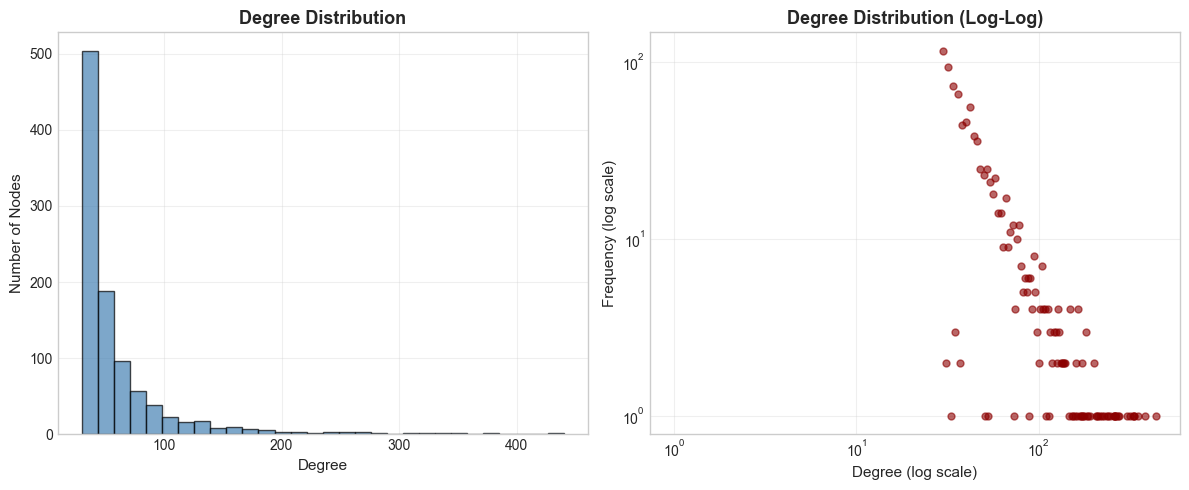

In [6]:
# Visualize degree distribution
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(degree_values, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Degree', fontsize=11)
plt.ylabel('Number of Nodes', fontsize=11)
plt.title('Degree Distribution', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

# Log-log plot
plt.subplot(1, 2, 2)
degree_counts = nx.degree_histogram(social_network)
degrees_range = range(len(degree_counts))
plt.loglog(degrees_range, degree_counts, 'o', markersize=5, alpha=0.6, color='darkred')
plt.xlabel('Degree (log scale)', fontsize=11)
plt.ylabel('Frequency (log scale)', fontsize=11)
plt.title('Degree Distribution (Log-Log)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Centrality Measures

Centrality measures identify the most important nodes in the network.

### Degree Centrality

Identifies nodes with the most direct connections.

In [7]:
# Calculate degree centrality
degree_centrality = nx.degree_centrality(social_network)

# Find top 5 most central nodes
top_5_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Nodes by Degree Centrality:")
for i, (node, centrality) in enumerate(top_5_degree, 1):
    print(f"  {i}. Node {node}: {centrality:.4f}")

Top 5 Nodes by Degree Centrality:
  1. Node 2: 0.4435
  2. Node 25: 0.3851
  3. Node 23: 0.3528
  4. Node 18: 0.3367
  5. Node 21: 0.3347


### Betweenness Centrality

Identifies nodes that act as bridges between different parts of the network.

In [8]:
# Calculate betweenness centrality (may take time for large networks)
# Use a sample if network is very large
if social_network.number_of_nodes() > 1000:
    print("Large network detected. Computing approximate betweenness...")
    betweenness = nx.betweenness_centrality(social_network, k=100)  # Sample 100 nodes
else:
    betweenness = nx.betweenness_centrality(social_network)

top_5_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Nodes by Betweenness Centrality:")
for i, (node, centrality) in enumerate(top_5_betweenness, 1):
    print(f"  {i}. Node {node}: {centrality:.4f}")

Top 5 Nodes by Betweenness Centrality:
  1. Node 2: 0.0405
  2. Node 25: 0.0325
  3. Node 23: 0.0279
  4. Node 18: 0.0253
  5. Node 28: 0.0235


## 4. Mention Network

The mention network shows who mentions whom in their posts.

In [9]:
# Extract mention network
mention_network = ydh.mention_network()

print("Mention Network Statistics:")
print(f"  Nodes: {mention_network.number_of_nodes()}")
print(f"  Edges (Mentions): {mention_network.number_of_edges()}")
print(f"  Density: {nx.density(mention_network):.4f}")

Mention Network Statistics:
  Nodes: 956
  Edges (Mentions): 11598
  Density: 0.0127


## 5. Ego Networks

An ego network contains a focal node and all nodes connected to it.

In [10]:
# Get ego network for a specific agent
focal_agent = 3  # Change to any agent ID
ego_net = ydh.ego_network(focal_agent)

print(f"Ego Network for Agent {focal_agent}:")
print(f"  Nodes: {ego_net.number_of_nodes()}")
print(f"  Edges: {ego_net.number_of_edges()}")
print(f"  Degree of focal node: {ego_net.degree(focal_agent)}")

Ego Network for Agent 3:
  Nodes: 65
  Edges: 128
  Degree of focal node: 128


### Visualizing an Ego Network

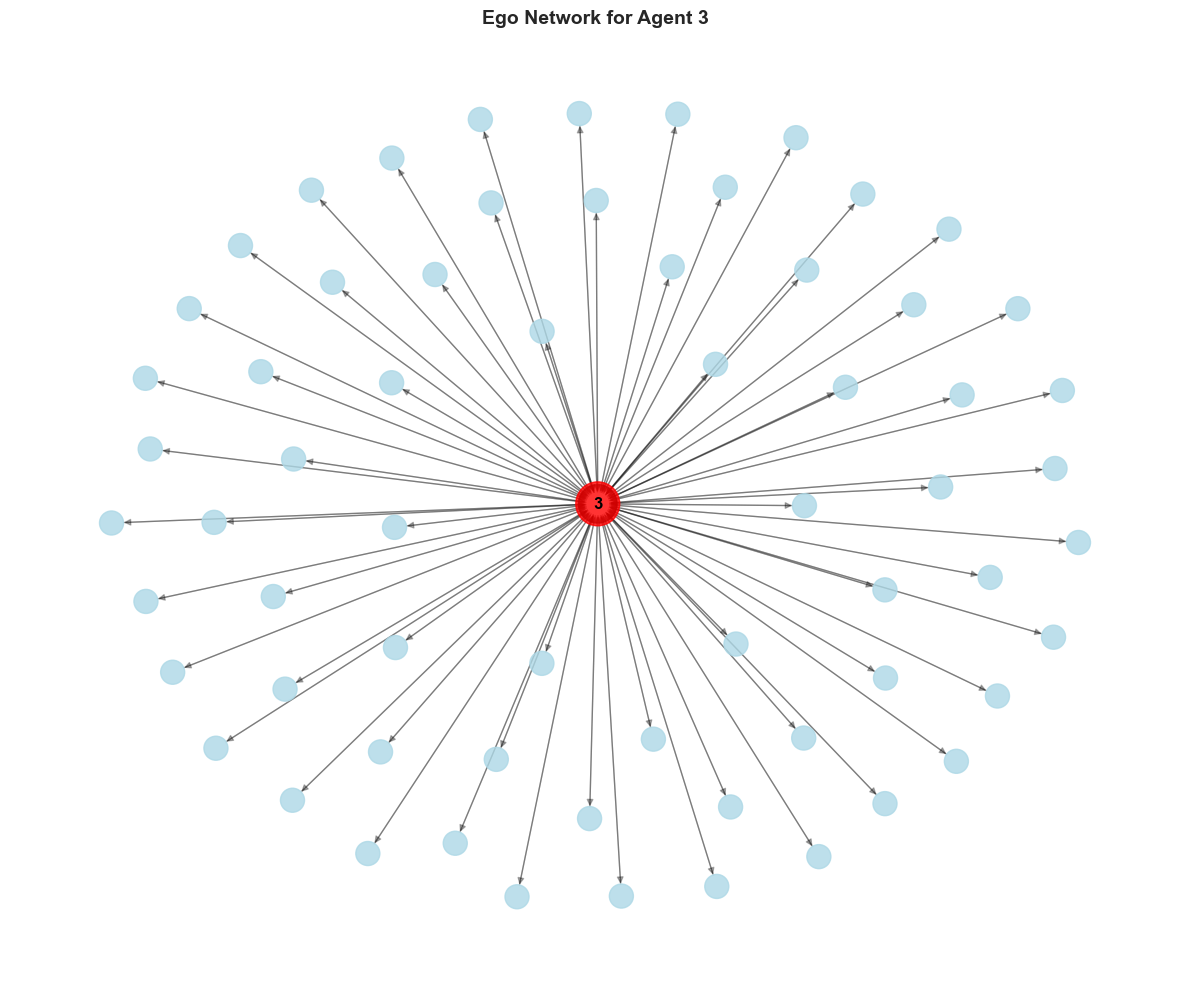

In [11]:
# Create visualization of ego network
plt.figure(figsize=(12, 10))

# Position nodes using spring layout
pos = nx.spring_layout(ego_net, k=0.5, iterations=50, seed=42)

# Draw nodes
# Focal node in red, others in blue
node_colors = ['red' if node == focal_agent else 'lightblue' for node in ego_net.nodes()]
node_sizes = [1000 if node == focal_agent else 300 for node in ego_net.nodes()]

nx.draw_networkx_nodes(ego_net, pos, 
                       node_color=node_colors, 
                       node_size=node_sizes,
                       alpha=0.8)

# Draw edges
nx.draw_networkx_edges(ego_net, pos, alpha=0.3, arrows=True, arrowsize=10)

# Draw labels
labels = {node: str(node) if node == focal_agent else '' for node in ego_net.nodes()}
nx.draw_networkx_labels(ego_net, pos, labels, font_size=12, font_weight='bold')

plt.title(f'Ego Network for Agent {focal_agent}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Community Detection

Identify communities or clusters within the network.

In [12]:
# Use Louvain method for community detection
# Convert to undirected for community detection
undirected_network = social_network.to_undirected()

# Requires python-louvain package
try:
    import community as community_louvain
    communities = community_louvain.best_partition(undirected_network)
    
    # Count communities
    num_communities = len(set(communities.values()))
    print(f"Number of Communities Detected: {num_communities}")
    
    # Community sizes
    community_sizes = {}
    for node, comm_id in communities.items():
        community_sizes[comm_id] = community_sizes.get(comm_id, 0) + 1
    
    print("\nCommunity Sizes:")
    for comm_id, size in sorted(community_sizes.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  Community {comm_id}: {size} nodes")
        
except ImportError:
    print("python-louvain not installed. Install with: pip install python-louvain")

python-louvain not installed. Install with: pip install python-louvain


## 7. Network Comparison

Compare social network with mention network.

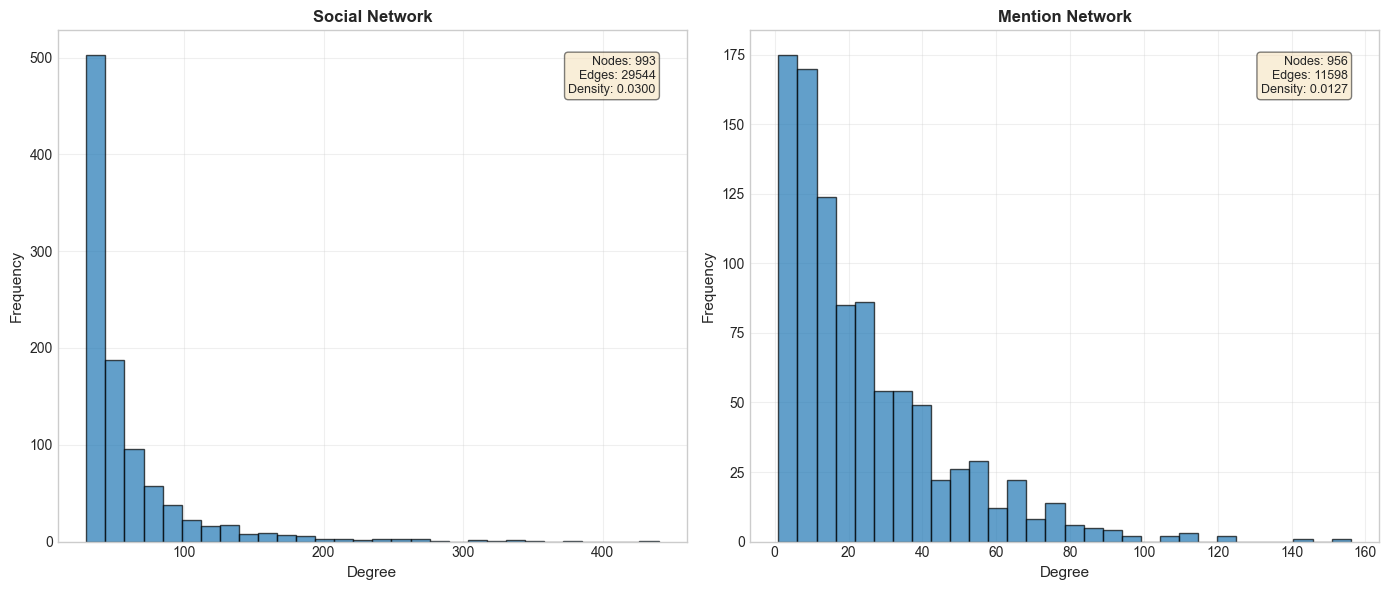

In [13]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

networks = [social_network, mention_network]
titles = ['Social Network', 'Mention Network']

for ax, net, title in zip(axes, networks, titles):
    degrees = [d for n, d in net.degree()]
    ax.hist(degrees, bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Degree', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    ax.text(0.95, 0.95, 
            f'Nodes: {net.number_of_nodes()}\nEdges: {net.number_of_edges()}\nDensity: {nx.density(net):.4f}',
            transform=ax.transAxes, 
            fontsize=9,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Summary

In this tutorial, you learned:

✓ How to extract social and mention networks from simulation data  
✓ Computing basic network statistics (density, degree distribution)  
✓ Calculating centrality measures to identify important nodes  
✓ Analyzing ego networks for individual agents  
✓ Detecting communities within networks  
✓ Visualizing network structures  
✓ Comparing different types of networks  

## Next Steps

- **Algorithms Tutorial**: Learn about profile similarity, paradox detection, and recommendation metrics
- **Visualization Tutorial**: Create advanced visualizations of simulation data